In [1]:
# # 04 - Churn (repeat-purchase) model
#
# Target: did a first-time customer order again within 180 days?
# Base rate ~1.8%, so **accuracy is meaningless** - predicting "everyone churns"
# scores 98.4% accuracy with zero recall.
#
# Headline metric is **PR-AUC**, reported as lift over the base rate.
# Three models: logistic baseline, Random Forest, XGBoost.

import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("project root :", ROOT)

project root : c:\DS-AI-Spiced\PropheticIQ_AI_Powered_Ecom_Platform


In [2]:
%pip install shap xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, roc_curve

from src.models.churn import (
    CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET, TS_COL,
    assert_no_leakage, evaluate, make_models, time_split_three, tune_threshold,
)
from src.viz.style import PALETTE, apply_style

apply_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIG = ROOT / "reports" / "figures" / "churn"
MODELS.mkdir(exist_ok=True); FIG.mkdir(parents=True, exist_ok=True)

def show(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")
    return fig

In [4]:
# ## Load features and check for leakage
#
# The guard raises if any customer-level aggregate (which would include the
# second order) has crept into the feature list.

path = PROCESSED / "churn_features.parquet"
churn = (pd.read_parquet(path) if path.exists()
         else pd.read_csv(PROCESSED / "churn_features.csv", parse_dates=[TS_COL]))

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
assert_no_leakage(FEATURES)
print(f"{len(churn):,} customers | {len(FEATURES)} features | "
      f"positives {churn[TARGET].sum():,} ({churn[TARGET].mean():.2%})")

57,049 customers | 28 features | positives 1,024 (1.79%)


In [5]:
# ## Temporal split: train / validation / test
#
# Chronological, never random. The validation set exists so the decision
# threshold is chosen without touching test - tuning on test then reporting
# test metrics is a subtle form of leakage.

train, val, test = time_split_three(churn, val_size=0.2, test_size=0.2)
split_tbl = pd.DataFrame([
    {"split": n, "rows": len(d), "start": d[TS_COL].min().date(),
     "end": d[TS_COL].max().date(), "positives": int(d[TARGET].sum()),
     "rate": d[TARGET].mean()}
    for n, d in [("train", train), ("val", val), ("test", test)]
]).set_index("split")
print(split_tbl.round(4).to_string())

        rows       start         end  positives    rate
split                                                  
train  34229  2017-01-05  2017-11-23        667  0.0195
val    11410  2017-11-23  2018-01-12        172  0.0151
test   11410  2018-01-12  2018-03-03        185  0.0162


In [6]:
# ## Why accuracy is misleading - the do-nothing baseline

naive_acc = 1 - test[TARGET].mean()
print(f"Predict 'everyone churns':")
print(f"  accuracy  {naive_acc:.4f}   <- looks excellent")
print(f"  recall    0.0000   <- identifies nobody to act on")
print(f"  PR-AUC    {test[TARGET].mean():.4f}   <- equals the base rate; this is the floor")

Predict 'everyone churns':
  accuracy  0.9838   <- looks excellent
  recall    0.0000   <- identifies nobody to act on
  PR-AUC    0.0162   <- equals the base rate; this is the floor


In [7]:
# ## Train the three models
#
# * **Logistic Regression** - the baseline that must be beaten. Linear, so it
#   can only use the delivery cliff through our engineered threshold features.
# * **Random Forest** - bagged trees, captures interactions, different bias.
# * **XGBoost** - boosted trees, handles NaN natively (2% never delivered),
#   `scale_pos_weight` for the ~50:1 imbalance.
#
# Reweighting rather than SMOTE: with only ~667 training positives, synthetic
# minority examples would outnumber real ones and the model would learn the
# interpolation, not the customers.

scale_pos_weight = (train[TARGET] == 0).sum() / (train[TARGET] == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

models = make_models(scale_pos_weight)
proba_val, proba_test, thresholds = {}, {}, {}

for name, model in models.items():
    model.fit(train[FEATURES], train[TARGET])
    proba_val[name] = model.predict_proba(val[FEATURES])[:, 1]
    proba_test[name] = model.predict_proba(test[FEATURES])[:, 1]
    thresholds[name] = tune_threshold(val[TARGET].to_numpy(), proba_val[name])
    print(f"  {name:14s} fitted, threshold from validation = {thresholds[name]:.4f}")

scale_pos_weight = 50.3
  logistic       fitted, threshold from validation = 0.6007
  random_forest  fitted, threshold from validation = 0.4548
  xgboost        fitted, threshold from validation = 0.4393


In [8]:
# ## Compare on the test set

rows = []
for name in models:
    m = evaluate(test[TARGET].to_numpy(), proba_test[name], thresholds[name])
    m["model"] = name
    rows.append(m)

comparison = pd.DataFrame(rows).set_index("model")[
    ["pr_auc", "pr_auc_lift", "roc_auc", "precision", "recall", "f1",
     "accuracy", "tp", "fp", "fn", "flagged", "threshold"]
]
print(comparison.round(4).to_string())
print(f"\nbase rate (PR-AUC floor): {test[TARGET].mean():.4f}")

               pr_auc  pr_auc_lift  roc_auc  precision  recall      f1  accuracy  tp    fp   fn  flagged  threshold
model                                                                                                              
logistic       0.0212       1.3094   0.5659     0.0239  0.1081  0.0391    0.9138  20   818  165      838     0.6007
random_forest  0.0213       1.3159   0.5541     0.0211  0.4054  0.0401    0.6855  75  3478  110     3553     0.4548
xgboost        0.0194       1.1964   0.5540     0.0219  0.1676  0.0388    0.8654  31  1382  154     1413     0.4393

base rate (PR-AUC floor): 0.0162


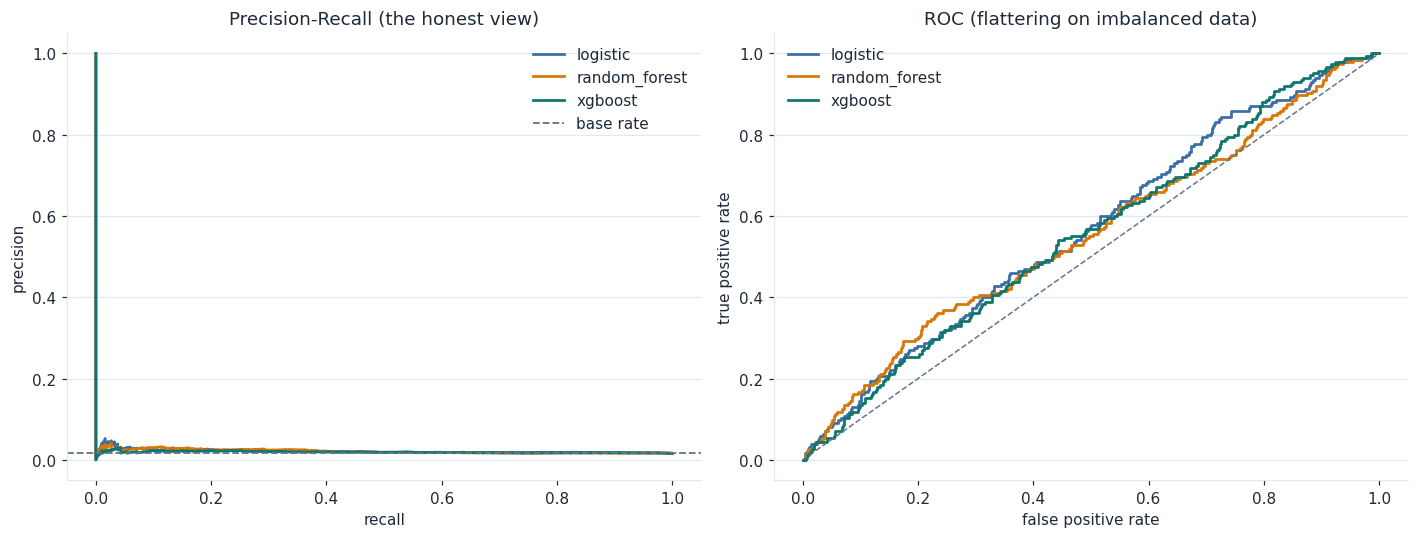

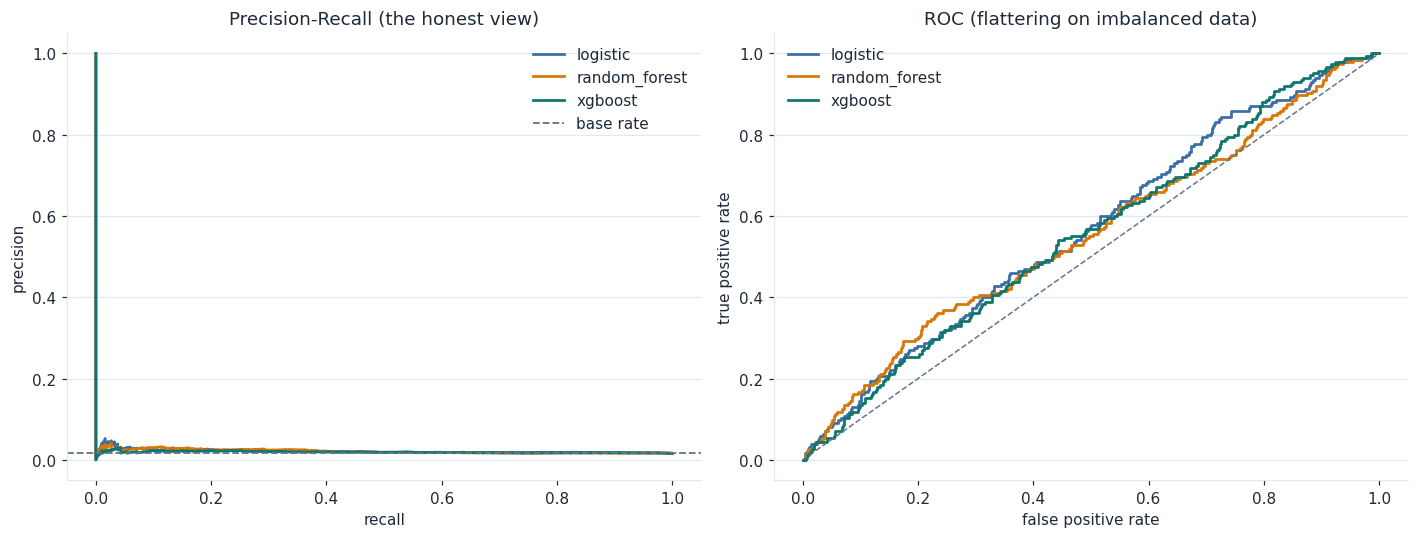

In [9]:
# ## Curves
#
# PR curve matters more than ROC here. ROC uses the false-positive *rate*,
# whose denominator is the 11,225 negatives - so ROC looks respectable even
# when precision is terrible.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, name in enumerate(models):
    p, r, _ = precision_recall_curve(test[TARGET], proba_test[name])
    axes[0].plot(r, p, color=PALETTE[i], lw=1.8, label=name)
    fpr, tpr, _ = roc_curve(test[TARGET], proba_test[name])
    axes[1].plot(fpr, tpr, color=PALETTE[i], lw=1.8, label=name)

axes[0].axhline(test[TARGET].mean(), color=PALETTE[5], ls="--", lw=1.2,
                label="base rate")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Precision-Recall (the honest view)"); axes[0].legend()
axes[1].plot([0, 1], [0, 1], "--", color=PALETTE[5], lw=1)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC (flattering on imbalanced data)"); axes[1].legend()
fig.tight_layout()
show(fig, "curves")

best by PR-AUC: random_forest


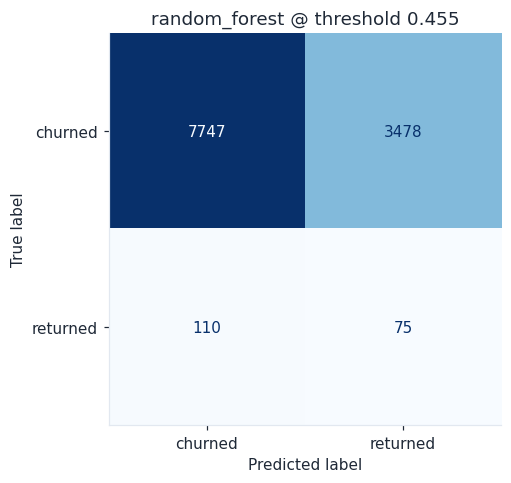

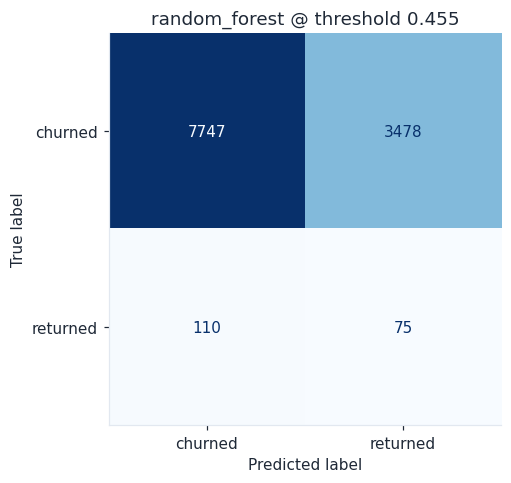

In [10]:
# ## Pick the best model by PR-AUC, then look at its confusion matrix

best_name = comparison["pr_auc"].idxmax()
best_model = models[best_name]
print(f"best by PR-AUC: {best_name}")

pred = (proba_test[best_name] >= thresholds[best_name]).astype(int)
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    test[TARGET], pred, display_labels=["churned", "returned"],
    cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"{best_name} @ threshold {thresholds[best_name]:.3f}")
ax.grid(False)
fig.tight_layout()
show(fig, "confusion_matrix")

In [11]:
# ## Business threshold: what a campaign would actually use
#
# F1 weights precision and recall equally, which no campaign does. The real
# question is "how many customers can we afford to contact, and what fraction
# of returners do we catch?" Sweep the budget instead.

budget_rows = []
for pct in [0.01, 0.02, 0.05, 0.10, 0.20]:
    t = np.quantile(proba_test[best_name], 1 - pct)
    m = evaluate(test[TARGET].to_numpy(), proba_test[best_name], t)
    budget_rows.append({
        "contact_top_pct": f"{pct:.0%}",
        "customers_contacted": m["flagged"],
        "returners_found": m["tp"],
        "precision": m["precision"],
        "recall": m["recall"],
        "lift_vs_random": m["precision"] / m["base_rate"],
    })
print(pd.DataFrame(budget_rows).to_string(index=False))

# `lift_vs_random` is the number that matters to a marketer: contacting the
# model's top decile versus a random decile. Below ~1.5x, a campaign is not
# worth running.

contact_top_pct  customers_contacted  returners_found  precision   recall  lift_vs_random
             1%                  115                4   0.034783 0.021622        2.145241
             2%                  229                7   0.030568 0.037838        1.885283
             5%                  571               17   0.029772 0.091892        1.836229
            10%                 1141               31   0.027169 0.167568        1.675676
            20%                 2282               55   0.024102 0.297297        1.486486


In [12]:
# ## Error analysis
#
# Where does the model fail, and is the failure structured or random?

err = test.copy()
err["proba"] = proba_test[best_name]
err["pred"] = pred
err["outcome"] = np.select(
    [(err[TARGET] == 1) & (err.pred == 1), (err[TARGET] == 1) & (err.pred == 0),
     (err[TARGET] == 0) & (err.pred == 1)],
    ["true positive", "false negative", "false positive"], default="true negative")

print(err["outcome"].value_counts().to_string())
print()
cols = ["revenue", "freight_ratio", "n_items", "delivery_days", "days_late",
        "review_score", "max_installments"]
print(err.groupby("outcome")[cols].median().round(2).to_string())

outcome
true negative     7747
false positive    3478
false negative     110
true positive       75

                revenue  freight_ratio  n_items  delivery_days  days_late  review_score  max_installments
outcome                                                                                                  
false negative    97.74           0.21      1.0          14.45        0.0           4.0               1.0
false positive    85.00           0.22      1.0          10.31        0.0           5.0               2.0
true negative     85.71           0.22      1.0          15.81        0.0           4.0               1.0
true positive     93.60           0.22      1.0           9.83        0.0           5.0               1.0


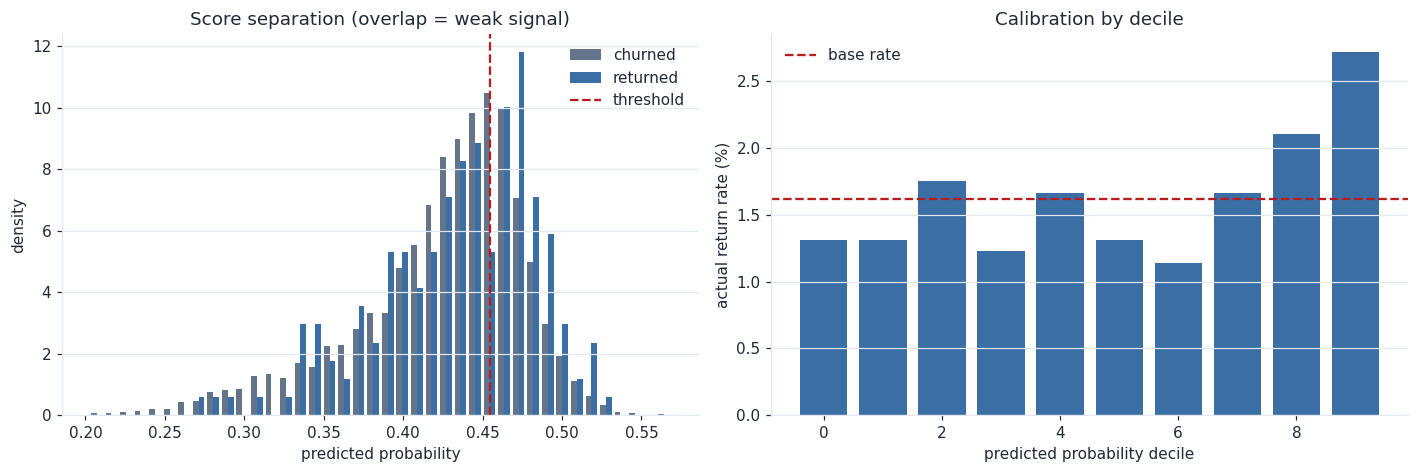

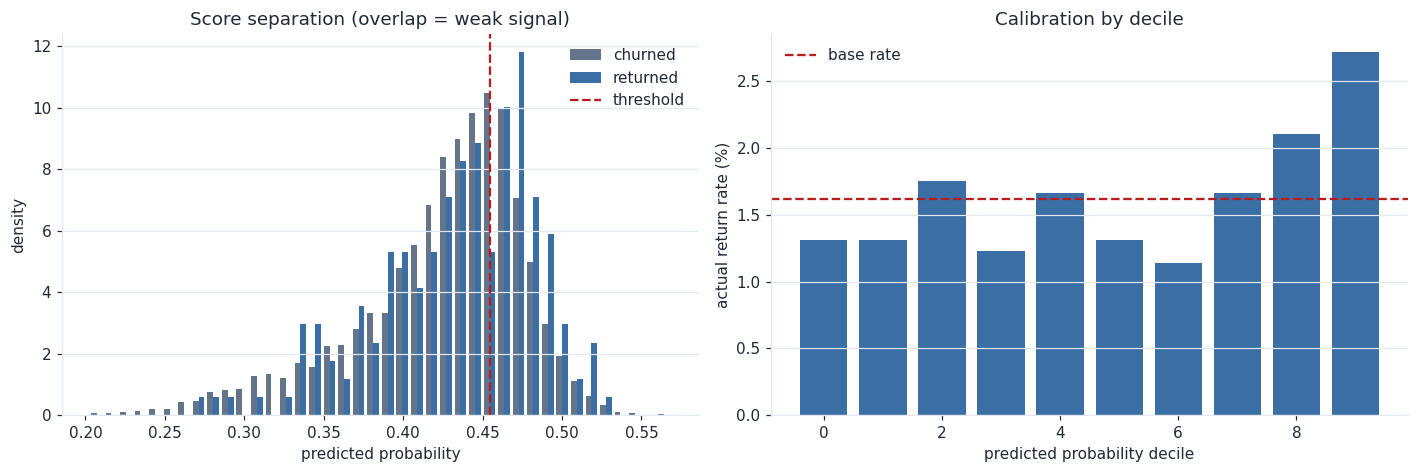

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].hist([err.loc[err[TARGET] == 0, "proba"], err.loc[err[TARGET] == 1, "proba"]],
             bins=40, label=["churned", "returned"], density=True,
             color=[PALETTE[5], PALETTE[0]])
axes[0].axvline(thresholds[best_name], color=PALETTE[3], ls="--",
                label="threshold")
axes[0].set_xlabel("predicted probability"); axes[0].set_ylabel("density")
axes[0].set_title("Score separation (overlap = weak signal)"); axes[0].legend()

decile = pd.qcut(err["proba"], 10, labels=False, duplicates="drop")
by_dec = err.groupby(decile)[TARGET].mean() * 100
axes[1].bar(by_dec.index, by_dec.values, color=PALETTE[0])
axes[1].axhline(test[TARGET].mean() * 100, color=PALETTE[3], ls="--",
                label="base rate")
axes[1].set_xlabel("predicted probability decile"); axes[1].set_ylabel("actual return rate (%)")
axes[1].set_title("Calibration by decile"); axes[1].legend()
fig.tight_layout()
show(fig, "error_analysis")

In [14]:
# ## SHAP - what drives the predictions
#
# SHAP assigns each feature a signed contribution per prediction, summing to
# the difference from the average prediction. Unlike gain-based importance it
# gives direction, not just magnitude.

import shap
import numpy as np

# Explain the model that is actually DEPLOYED, not whichever is conventional.
explained = best_model
prep = explained.named_steps["prep"]
clf = explained.named_steps["clf"]
print(f"explaining the DEPLOYED model: {best_name} ({type(clf).__name__})")

sample = test.sample(min(2000, len(test)), random_state=42)
X_trans = prep.transform(sample[FEATURES])
feat_names = list(prep.get_feature_names_out())
background = prep.transform(train[FEATURES].sample(500, random_state=42))

# shap >= 0.45 returns different shapes per model family:
#   XGBClassifier          -> (n, features)
#   RandomForestClassifier -> (n, features, n_classes)   <-- your error
# and TreeExplainer does not accept LogisticRegression at all.
if type(clf).__name__ in {"LogisticRegression", "LinearSVC", "SGDClassifier"}:
    explainer = shap.LinearExplainer(clf, background)
else:
    explainer = shap.TreeExplainer(clf)

raw = explainer.shap_values(X_trans)
if isinstance(raw, list):
    shap_values = np.asarray(raw[1] if len(raw) > 1 else raw[0])
else:
    raw = np.asarray(raw)
    shap_values = raw[:, :, 1] if raw.ndim == 3 else raw

print(f"SHAP: {shap_values.shape[0]:,} rows x {shap_values.shape[1]} features")

c:\DS-AI-Spiced\Product_Review-Sentiment_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


explaining the DEPLOYED model: random_forest (RandomForestClassifier)
SHAP: 2,000 rows x 88 features


num__month_of_year                       0.0159
num__delivery_days                       0.0100
num__freight                             0.0090
num__review_score                        0.0071
num__max_installments                    0.0056
num__comment_length                      0.0052
num__days_early                          0.0052
num__avg_item_price                      0.0051
num__revenue                             0.0043
num__days_late                           0.0042
num__freight_ratio                       0.0041
num__total_weight_g                      0.0041
cat__primary_category_cool_stuff         0.0039
num__log_revenue                         0.0039
cat__primary_category_cama_mesa_banho    0.0038


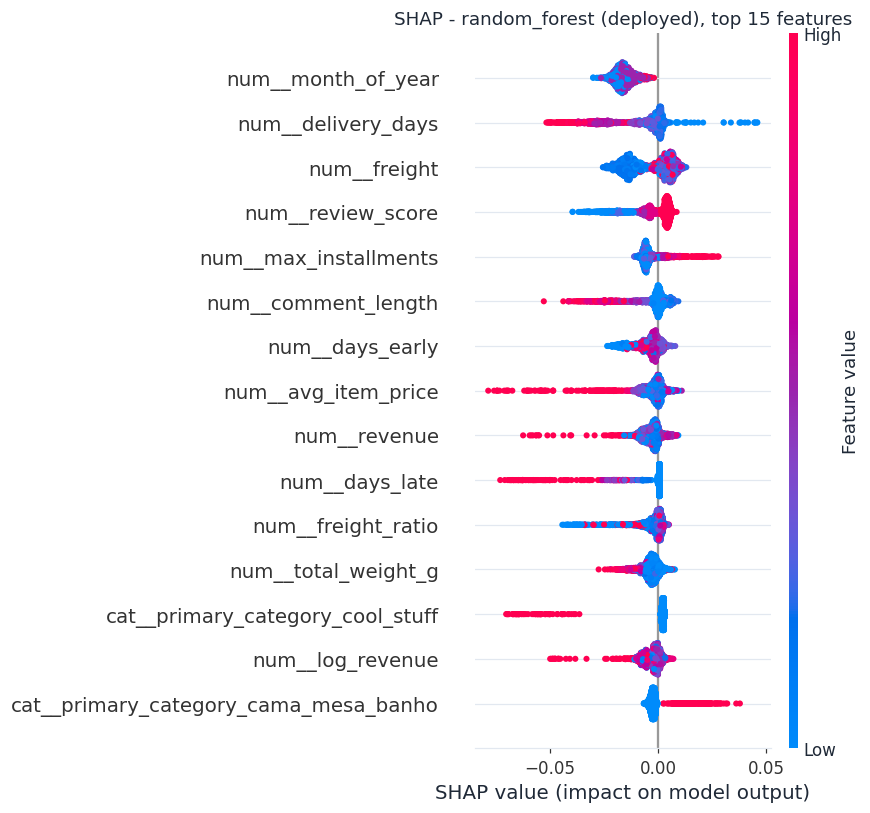

In [15]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_trans, feature_names=feat_names,
                  max_display=15, show=False)
plt.title(f"SHAP - {best_name} (deployed), top 15 features")
plt.tight_layout()
show(plt.gcf(), "shap_summary")

mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=feat_names)
print(mean_abs.sort_values(ascending=False).head(15).round(4).to_string())

In [16]:
# ## Save the artifacts
#
# Threshold is saved alongside the model. A model without its threshold is
# unusable - `predict()` defaults to 0.5, which on a 1.8% base rate flags
# almost nobody.

joblib.dump(
    {"model": best_model, "model_name": best_name,
     "threshold": thresholds[best_name], "features": FEATURES,
     "target": TARGET, "test_metrics": comparison.loc[best_name].to_dict()},
    MODELS / "churn_model.joblib",
)
comparison.to_csv(PROCESSED / "churn_model_comparison.csv")
print(f"saved models/churn_model.joblib ({best_name}, threshold {thresholds[best_name]:.4f})")

saved models/churn_model.joblib (random_forest, threshold 0.4548)
